# preparing the tools
in tools we are going to use pandas, matplotlib, and numpy for data analysis and manipulation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

#models from scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

#model evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

# load csv

In [2]:
df = pd.read_csv("dataset.csv")

In [13]:
df.head()

,index,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [14]:
df.tail()

,index,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
11050,11051,1,-1,1,-1,1,1,1,1,-1,...,-1,-1,1,1,-1,-1,1,1,1,1
11051,11052,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,1,1,1,1,1,1,-1,1,-1
11052,11053,1,-1,1,1,1,-1,1,-1,-1,...,1,1,1,1,1,-1,1,0,1,-1
11053,11054,-1,-1,1,1,1,-1,-1,-1,1,...,-1,1,1,1,1,-1,1,1,1,-1
11054,11055,-1,-1,1,1,1,-1,-1,-1,1,...,1,1,-1,1,-1,-1,-1,1,-1,-1


In [3]:
df["Result"].value_counts()

Result
 1    6157
-1    4898
Name: count, dtype: int64

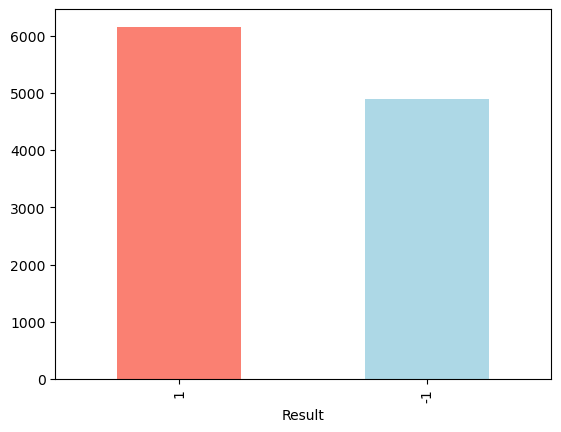

In [4]:
df["Result"].value_counts().plot(kind="bar", color=["salmon","lightblue"])
plt.show();

In [5]:
#checking for missing values
df.isnull().sum()

index                          0
having_IPhaving_IP_Address     0
URLURL_Length                  0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
port                           0
HTTPS_token                    0
Request_URL                    0
URL_of_Anchor                  0
Links_in_tags                  0
SFH                            0
Submitting_to_email            0
Abnormal_URL                   0
Redirect                       0
on_mouseover                   0
RightClick                     0
popUpWidnow                    0
Iframe                         0
age_of_domain                  0
DNSRecord                      0
web_traffic                    0
Page_Rank                      0
Google_Index                   0
Links_pointing_to_page         0
Statistica

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   index                        11055 non-null  int64
 1   having_IPhaving_IP_Address   11055 non-null  int64
 2   URLURL_Length                11055 non-null  int64
 3   Shortining_Service           11055 non-null  int64
 4   having_At_Symbol             11055 non-null  int64
 5   double_slash_redirecting     11055 non-null  int64
 6   Prefix_Suffix                11055 non-null  int64
 7   having_Sub_Domain            11055 non-null  int64
 8   SSLfinal_State               11055 non-null  int64
 9   Domain_registeration_length  11055 non-null  int64
 10  Favicon                      11055 non-null  int64
 11  port                         11055 non-null  int64
 12  HTTPS_token                  11055 non-null  int64
 13  Request_URL                  11055 non-null  i

In [19]:
df.describe()

,index,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
count,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,...,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000
mean,5528.000000,0.313795,-0.633198,0.738761,0.700588,0.741474,-0.734962,0.063953,0.250927,-0.336771,...,0.613388,0.816915,0.061239,0.377114,0.287291,-0.483673,0.721574,0.344007,0.719584,0.113885
std,3191.447947,0.949534,0.766095,0.673998,0.713598,0.671011,0.678139,0.817518,0.911892,0.941629,...,0.789818,0.576784,0.998168,0.926209,0.827733,0.875289,0.692369,0.569944,0.694437,0.993539
min,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,2764.500000,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,5528.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000,1.000000
75%,8291.500000,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,11055.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
X = df.drop('Result', axis=1)
y = df['Result']

In [21]:
X

,index,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,RightClick,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,1,-1,-1,-1,-1,1,1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,1,-1,-1,0,-1,1,1,1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,1,-1,1,-1,1,0,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,1,-1,-1,1,-1,1,-1,1
4,5,1,0,-1,1,1,-1,1,1,-1,...,1,-1,1,-1,-1,0,-1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11050,11051,1,-1,1,-1,1,1,1,1,-1,...,-1,-1,-1,1,1,-1,-1,1,1,1
11051,11052,-1,1,1,-1,-1,-1,1,-1,-1,...,1,-1,1,1,1,1,1,1,-1,1
11052,11053,1,-1,1,1,1,-1,1,-1,-1,...,1,1,1,1,1,1,-1,1,0,1
11053,11054,-1,-1,1,1,1,-1,-1,-1,1,...,1,-1,1,1,1,1,-1,1,1,1


In [22]:
y

0       -1
1       -1
2       -1
3       -1
4        1
        ..
11050    1
11051   -1
11052   -1
11053   -1
11054   -1
Name: Result, Length: 11055, dtype: int64

In [10]:
#splitting the data
np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [11]:
X_train

,index,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,RightClick,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report
480,481,1,-1,1,1,1,-1,1,1,-1,...,1,1,1,1,1,1,-1,1,0,1
10812,10813,-1,-1,1,1,1,-1,0,1,1,...,1,1,1,1,1,0,-1,-1,0,1
4064,4065,1,1,1,1,1,1,0,1,-1,...,1,1,1,-1,1,0,-1,-1,0,1
8225,8226,-1,-1,-1,-1,-1,-1,1,-1,-1,...,1,1,1,1,-1,0,-1,-1,1,1
9432,9433,-1,-1,1,1,1,-1,-1,-1,-1,...,1,1,1,1,1,1,-1,-1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,5735,-1,0,1,1,1,-1,0,-1,1,...,1,1,1,-1,1,1,1,1,-1,1
5191,5192,1,1,1,-1,1,-1,1,-1,1,...,1,1,-1,-1,1,-1,1,1,0,1
5390,5391,-1,1,1,-1,1,-1,0,-1,1,...,1,1,-1,1,1,0,1,1,0,1
860,861,1,-1,1,1,1,-1,1,1,1,...,1,-1,-1,1,1,-1,-1,1,0,-1


In [12]:
y_train

480      1
10812   -1
4064     1
8225     1
9432    -1
        ..
5734    -1
5191    -1
5390    -1
860      1
7270    -1
Name: Result, Length: 8844, dtype: int64

In [13]:
models = {"Logistic Regression": LogisticRegression(),
          "KNN": KNeighborsClassifier(),
          "Random Forest": RandomForestClassifier()}

def fit_and_score(models, X_train, X_test, y_train, y_test):

    np.random.seed(42)
    #make a dictionary to keep model scores
    model_scores = {}
    #loop through models
    for name, model in models.items():
        #fit the model to the data
        model.fit(X_train, y_train)
        #evalaute the model and append its score to model_scores
        model_scores[name] = model.score(X_test, y_test)

    return model_scores

In [14]:
model_scores = fit_and_score(models = models,
                             X_train = X_train,
                             X_test = X_test,
                             y_train = y_train,
                             y_test = y_test)
model_scores

/Users/nandinibhatia/Desktop/sample_project/fraud-detection-project/env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regression': 0.9176843057440073,
 'KNN': 0.6033469018543646,
 'Random Forest': 0.9678878335594754}

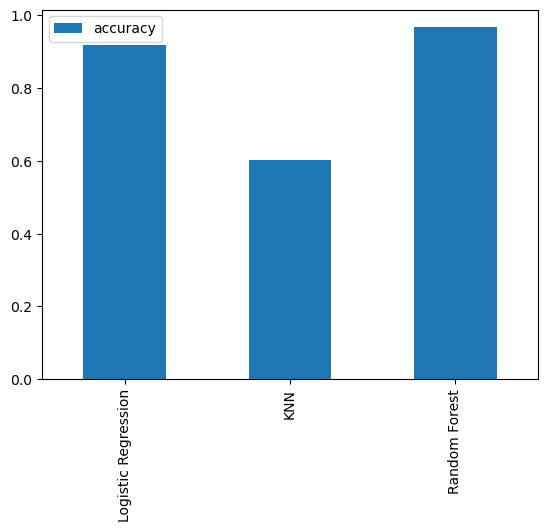

In [15]:
model_compare = pd.DataFrame(model_scores, index=["accuracy"])
model_compare.T.plot.bar();
plt.show();

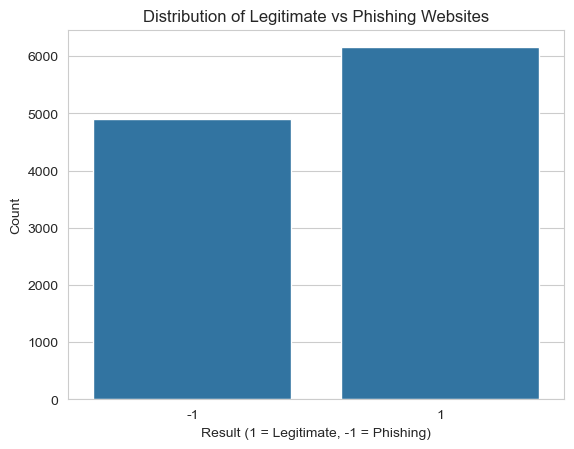

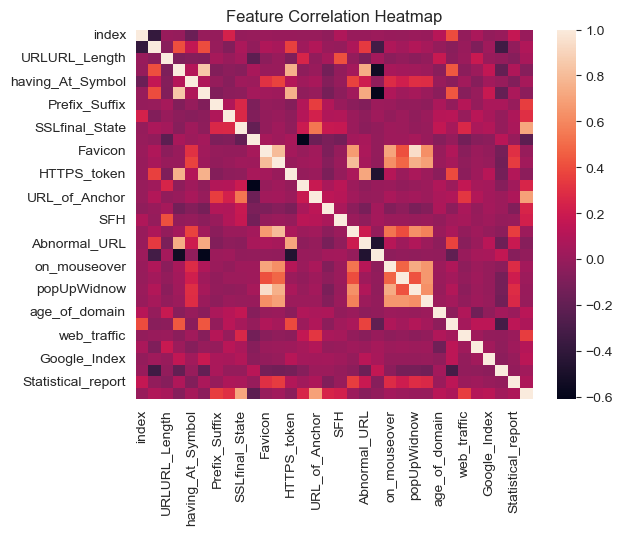

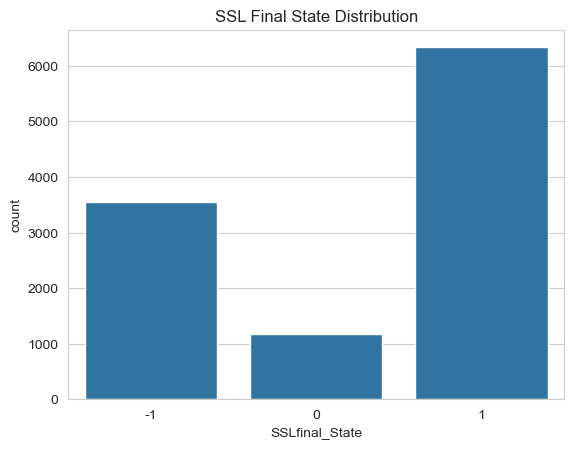

In [19]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("dataset.csv")   # change file name if needed

# Set style
sns.set_style("whitegrid")

# Class Distribution
plt.figure()
sns.countplot(x='Result', data=df)
plt.title("Distribution of Legitimate vs Phishing Websites")
plt.xlabel("Result (1 = Legitimate, -1 = Phishing)")
plt.ylabel("Count")
plt.show()

# Correlation Heatmap
plt.figure()
corr = df.corr()
sns.heatmap(corr)
plt.title("Feature Correlation Heatmap")
plt.show()

# Feature Distribution Example
plt.figure()
sns.countplot(x='SSLfinal_State', data=df)
plt.title("SSL Final State Distribution")
plt.show();

In [2]:
df = pd.read_csv("dataset1.csv")

In [3]:
df.head()

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1


In [4]:
df.tail()

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
235790,https://www.skincareliving.com,29,www.skincareliving.com,22,0,com,100.000000,1.000000,0.522907,0.058739,...,1,0,1,51,7,21,187,2,191,1
235791,https://www.winchester.gov.uk,28,www.winchester.gov.uk,21,0,uk,100.000000,0.785714,0.028555,0.053834,...,1,0,0,50,1,7,88,0,31,1
235792,https://www.nononsensedesign.be,30,www.nononsensedesign.be,23,0,be,100.000000,1.000000,0.003319,0.063093,...,0,0,1,27,10,30,58,2,67,1
235793,https://patient-cell-40f5.updatedlogmylogin.wo...,55,patient-cell-40f5.updatedlogmylogin.workers.dev,47,0,dev,28.157537,0.465116,0.000961,0.050211,...,0,0,0,0,0,3,0,0,0,0
235794,https://www.alternativefinland.com,33,www.alternativefinland.com,26,0,com,100.000000,1.000000,0.522907,0.060596,...,0,0,1,21,6,18,256,0,261,1


In [3]:
df["label"].value_counts()

label
1    134850
0    100945
Name: count, dtype: int64

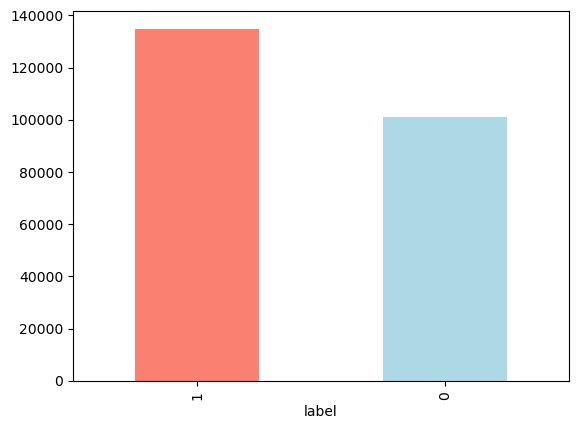

In [4]:
df["label"].value_counts().plot(kind="bar", color=["salmon","lightblue"])
plt.show();

In [8]:
#checking for missing values
df.isnull().sum()

URL                           0
URLLength                     0
Domain                        0
DomainLength                  0
IsDomainIP                    0
TLD                           0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
LineOfCode                    0
LargestLineLength             0
HasTitle                      0
Title                         0
DomainTitleMatchScore         0
URLTitleMatchScore            0
HasFavic

In [3]:
# Drop non-numeric / unnecessary columns
df = df.drop(columns=["URL", "Domain", "Title", "TLD"], errors='ignore')

# Features
X = df.drop("label", axis=1)

# Target
y = df["label"]

In [4]:
X = df.drop("label", axis=1)
y = df["label"]

In [30]:
X

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef
0,31,24,0,100.000000,1.000000,0.522907,0.061933,3,1,0,...,1,0,0,1,34,20,28,119,0,124
1,23,16,0,100.000000,0.666667,0.032650,0.050207,2,1,0,...,0,0,0,1,50,9,8,39,0,217
2,29,22,0,100.000000,0.866667,0.028555,0.064129,2,2,0,...,0,0,0,1,10,2,7,42,2,5
3,26,19,0,100.000000,1.000000,0.522907,0.057606,3,1,0,...,0,1,1,1,3,27,15,22,1,31
4,33,26,0,100.000000,1.000000,0.079963,0.059441,3,1,0,...,1,1,0,1,244,15,34,72,1,85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235790,29,22,0,100.000000,1.000000,0.522907,0.058739,3,1,0,...,0,1,0,1,51,7,21,187,2,191
235791,28,21,0,100.000000,0.785714,0.028555,0.053834,2,2,0,...,0,1,0,0,50,1,7,88,0,31
235792,30,23,0,100.000000,1.000000,0.003319,0.063093,2,1,0,...,0,0,0,1,27,10,30,58,2,67
235793,55,47,0,28.157537,0.465116,0.000961,0.050211,3,2,0,...,0,0,0,0,0,0,3,0,0,0


In [25]:
y

0         1
1         1
2         1
3         1
4         1
         ..
235790    1
235791    1
235792    1
235793    0
235794    1
Name: label, Length: 235795, dtype: int64

In [5]:
#splitting the data
np.random.seed(42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [17]:
X_train

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Bank,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef
125096,https://3.daviplataactivo.repl.co/,33,3.daviplataactivo.repl.co,25,0,co,29.649226,0.772727,0.005977,0.056982,...,0,0,0,0,0,0,0,0,0,2
52769,http://www.ole32.com,19,www.ole32.com,13,0,com,68.148148,1.000000,0.522907,0.059038,...,0,0,0,0,0,0,0,0,0,0
202217,https://www.cowtales.com,23,www.cowtales.com,16,0,com,100.000000,1.000000,0.522907,0.068591,...,0,1,0,0,30,13,14,36,0,16
35039,https://miseenjourdigitalisation2023.web.app/,44,miseenjourdigitalisation2023.web.app,36,0,app,36.782616,0.906250,0.001502,0.050708,...,1,1,0,0,4,0,0,0,0,6
57443,https://www.karenlepage.me,25,www.karenlepage.me,18,0,me,100.000000,1.000000,0.003638,0.060428,...,0,1,0,0,14,4,15,72,0,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119879,https://www.greenmountainenergy.com,34,www.greenmountainenergy.com,27,0,com,100.000000,1.000000,0.522907,0.064465,...,1,1,0,1,26,6,16,169,15,40
103694,https://www.leadcastingcall.com,30,www.leadcastingcall.com,23,0,com,100.000000,1.000000,0.522907,0.063148,...,0,0,0,1,25,9,22,87,1,93
131932,https://aruba.serveice-mein-auth.com/kqtxa8j9v...,114,aruba.serveice-mein-auth.com,28,0,com,11.574038,0.375000,0.522907,0.038615,...,0,0,0,0,0,0,0,0,0,0
146867,https://www.fedarb.com,21,www.fedarb.com,14,0,com,100.000000,1.000000,0.522907,0.059510,...,0,0,0,1,24,36,48,102,1,50


In [18]:
print(X.dtypes)

URL                            object
URLLength                       int64
Domain                         object
DomainLength                    int64
IsDomainIP                      int64
TLD                            object
URLSimilarityIndex            float64
CharContinuationRate          float64
TLDLegitimateProb             float64
URLCharProb                   float64
TLDLength                       int64
NoOfSubDomain                   int64
HasObfuscation                  int64
NoOfObfuscatedChar              int64
ObfuscationRatio              float64
NoOfLettersInURL                int64
LetterRatioInURL              float64
NoOfDegitsInURL                 int64
DegitRatioInURL               float64
NoOfEqualsInURL                 int64
NoOfQMarkInURL                  int64
NoOfAmpersandInURL              int64
NoOfOtherSpecialCharsInURL      int64
SpacialCharRatioInURL         float64
IsHTTPS                         int64
LineOfCode                      int64
LargestLineL

In [6]:

models = {"Logistic Regression": LogisticRegression(),
          "KNN": KNeighborsClassifier(),
          "Random Forest": RandomForestClassifier()}

def fit_and_score(models, X_train, X_test, y_train, y_test):

    np.random.seed(42)
    #make a dictionary to keep model scores
    model_scores = {}
    #loop through models
    for name, model in models.items():
        #fit the model to the data
        model.fit(X_train, y_train)
        #evalaute the model and append its score to model_scores
        model_scores[name] = model.score(X_test, y_test)

    return model_scores

In [7]:
model_scores = fit_and_score(models = models,
                             X_train = X_train,
                             X_test = X_test,
                             y_train = y_train,
                             y_test = y_test)
model_scores

/Users/nandinibhatia/Desktop/sample_project/fraud-detection-project/env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regression': 0.9974130070612184,
 'KNN': 0.9976886702432197,
 'Random Forest': 1.0}

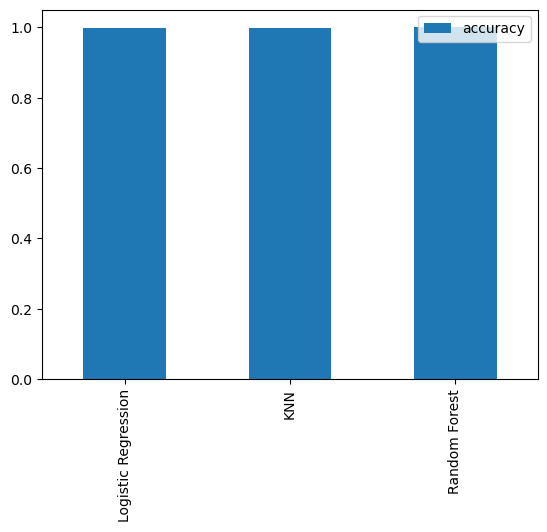

In [34]:
model_compare = pd.DataFrame(model_scores, index=["accuracy"])
model_compare.T.plot.bar();
plt.show();

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
!pip install tensorflow

In [39]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # binary classification
])

/Users/nandinibhatia/Desktop/sample_project/fraud-detection-project/env/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
4716/4716 ━━━━━━━━━━━━━━━━━━━━ 2s 323us/step - accuracy: 0.9987 - loss: 0.0052 - val_accuracy: 0.9998 - val_loss: 6.3154e-04
Epoch 2/20
4716/4716 ━━━━━━━━━━━━━━━━━━━━ 2s 317us/step - accuracy: 0.9998 - loss: 5.3467e-04 - val_accuracy: 0.9998 - val_loss: 0.0012
Epoch 3/20
4716/4716 ━━━━━━━━━━━━━━━━━━━━ 1s 314us/step - accuracy: 0.9999 - loss: 3.8049e-04 - val_accuracy: 0.9999 - val_loss: 5.6536e-04
Epoch 4/20
4716/4716 ━━━━━━━━━━━━━━━━━━━━ 2s 319us/step - accuracy: 0.9999 - loss: 2.4192e-04 - val_accuracy: 0.9998 - val_loss: 6.5584e-04
Epoch 5/20
4716/4716 ━━━━━━━━━━━━━━━━━━━━ 1s 316us/step - accuracy: 0.9999 - loss: 2.4944e-04 - val_accuracy: 0.9998 - val_loss: 5.9492e-04
Epoch 6/20
4716/4716 ━━━━━━━━━━━━━━━━━━━━ 2s 320us/step - accuracy: 0.9999 - loss: 2.0423e-04 - val_accuracy: 0.9999 - val_loss: 3.7385e-04
Epoch 7/20
4716/4716 ━━━━━━━━━━━━━━━━━━━━ 1s 315us/step - accuracy: 0.9999 - loss: 2.2221e-04 - val_accuracy: 0.9999 - val_loss: 4.2103e-04
Epoch 8/20
4716/4716 ━━━━━━━

In [15]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

1474/1474 ━━━━━━━━━━━━━━━━━━━━ 0s 206us/step - accuracy: 0.9999 - loss: 0.0019
Accuracy: 0.9998515844345093


In [16]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = (model.predict(X_test) > 0.5).astype("int32")

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

1474/1474 ━━━━━━━━━━━━━━━━━━━━ 0s 158us/step
[[20117     7]
 [    0 27035]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20124
           1       1.00      1.00      1.00     27035

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



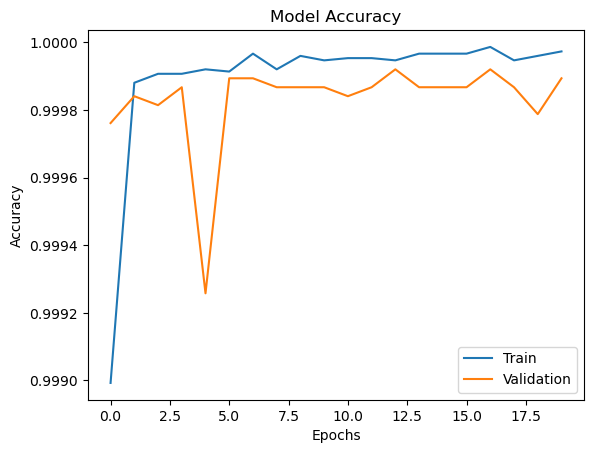

In [46]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int).flatten()

# Evaluate loss
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)

# Metrics
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

1474/1474 ━━━━━━━━━━━━━━━━━━━━ 0s 151us/step
1474/1474 ━━━━━━━━━━━━━━━━━━━━ 0s 203us/step - accuracy: 0.9999 - loss: 0.0019
Loss: 0.001886814134195447
Accuracy: 0.9998515844345093
[[20117     7]
 [    0 27035]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20124
           1       1.00      1.00      1.00     27035

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



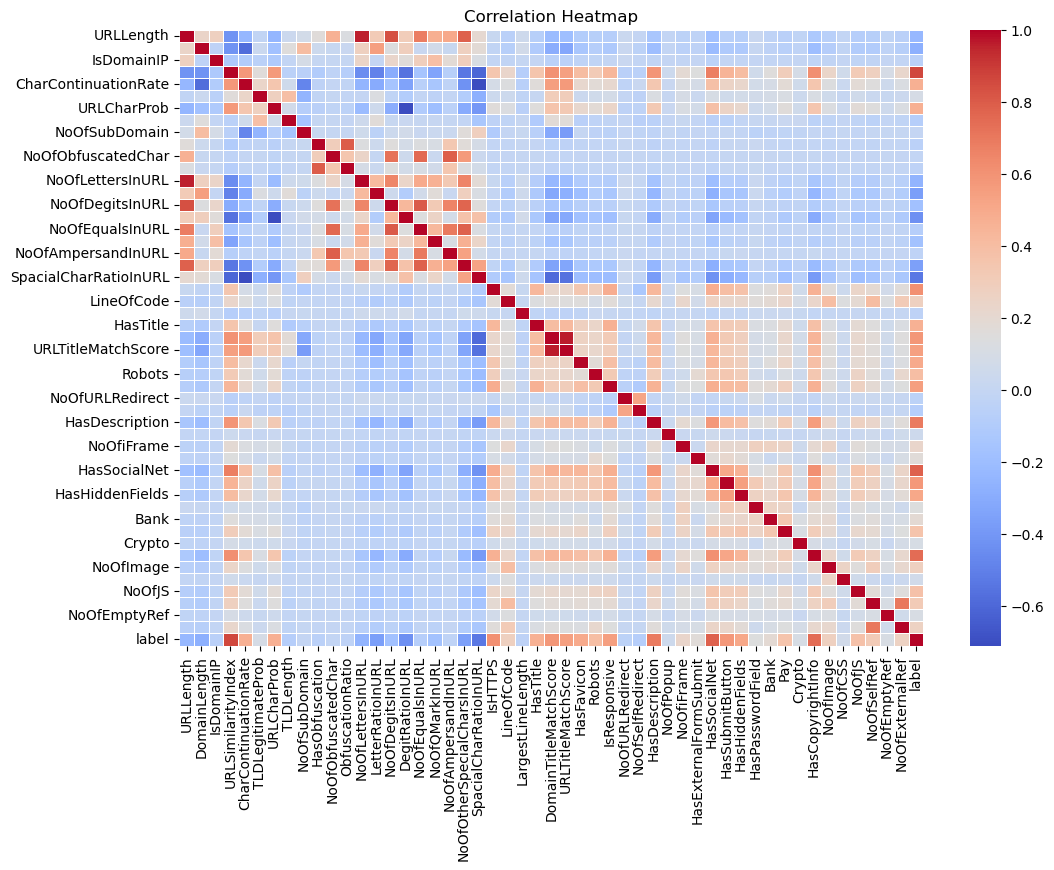

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr = df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show

<Figure size 600x400 with 0 Axes>

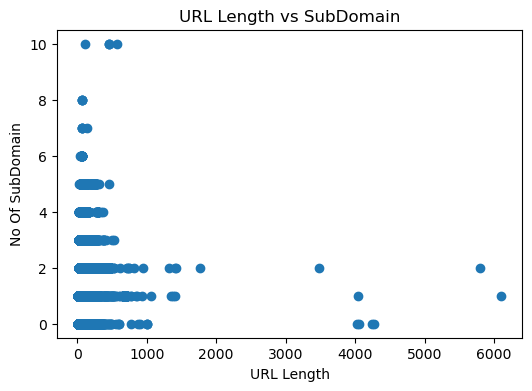

In [21]:
plt.figure(figsize=(6,4))
plt.scatter(df['URLLength'], df['NoOfSubDomain'])
plt.xlabel("URL Length")
plt.ylabel("No Of SubDomain")
plt.title("URL Length vs SubDomain")
plt.show()

In [10]:
print("label" in X.columns)

False


In [11]:
df = df.drop_duplicates()

In [12]:
train_test_split(X, y, test_size=0.2, random_state=42)

[        URLLength  DomainLength  IsDomainIP  URLSimilarityIndex  \
 125096         33            25           0           29.649226   
 52769          19            13           0           68.148148   
 202217         23            16           0          100.000000   
 35039          44            36           0           36.782616   
 57443          25            18           0          100.000000   
 ...           ...           ...         ...                 ...   
 119879         34            27           0          100.000000   
 103694         30            23           0          100.000000   
 131932        114            28           0           11.574038   
 146867         21            14           0          100.000000   
 121958         26            19           0          100.000000   
 
         CharContinuationRate  TLDLegitimateProb  URLCharProb  TLDLength  \
 125096              0.772727           0.005977     0.056982          2   
 52769               1.000000 

In [13]:
df.columns = df.columns.str.strip()

In [14]:
print(df.columns)

Index(['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex',
       'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength',
       'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar',
       'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL',
       'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL',
       'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon',
       'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect',
       'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit',
       'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields',
       'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo',
       'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef',
       'NoOfExternalRef', 'label'],
      dtype='object')


In [15]:
X = df.drop("label", axis=1)
y = df["label"]

In [16]:
print("label" in X.columns)  # MUST be False

False


In [17]:
leak_cols = [
    "URLSimilarityIndex",
    "DomainTitleMatchScore",
    "URLTitleMatchScore"
]

X = X.drop(columns=leak_cols, errors='ignore')

In [18]:
X = X.drop(columns=["URL", "Domain", "Title", "TLD"], errors='ignore')

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
from sklearn.model_selection import train_test_split

X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# NOW remove overlap properly
train_df = X_train.copy()
train_df["label"] = y_train

test_df = X_test.copy()
test_df["label"] = y_test

# Remove any duplicates between train & test
test_df = test_df[~test_df.apply(tuple,1).isin(train_df.apply(tuple,1))]

# Recreate X_test, y_test
y_test = test_df["label"]
X_test = test_df.drop("label", axis=1)

In [24]:
leak_cols = [
    "URLSimilarityIndex",
    "DomainTitleMatchScore",
    "URLTitleMatchScore",
    "TLDLegitimateProb",
    "URLCharProb"
]

X_train = X_train.drop(columns=leak_cols, errors='ignore')
X_test = X_test.drop(columns=leak_cols, errors='ignore')

In [31]:
print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.9998085024894676


In [26]:
leak_cols = [
    "URLSimilarityIndex",
    "DomainTitleMatchScore",
    "URLTitleMatchScore",
    "TLDLegitimateProb",
    "URLCharProb"
]

X = X.drop(columns=leak_cols, errors='ignore')

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [28]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
X_test = X_test[X_train.columns]

In [30]:
print(X_train.shape)
print(X_test.shape)

(187989, 45)
(46998, 45)


In [32]:
more_leak_cols = [
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "ObfuscationRatio",
    "HasHiddenFields",
    "HasPasswordField",
    "HasExternalFormSubmit"
]

X = X.drop(columns=more_leak_cols, errors='ignore')

In [34]:
import numpy as np

y_shuffled = np.random.permutation(y_train)

model.fit(X_train, y_shuffled)
print("Test Accuracy after shuffle:", model.score(X_test, y_test))

Test Accuracy after shuffle: 0.6014936805821525


In [35]:
import pandas as pd

importance = model.feature_importances_
feat_imp = pd.Series(importance, index=X_train.columns).sort_values(ascending=False)

print(feat_imp.head(10))

LargestLineLength        0.106469
LineOfCode               0.082630
NoOfExternalRef          0.063233
NoOfSelfRef              0.061381
NoOfImage                0.058172
NoOfJS                   0.052207
LetterRatioInURL         0.049505
CharContinuationRate     0.047069
SpacialCharRatioInURL    0.045377
NoOfCSS                  0.044676
dtype: float64


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# Models dictionary
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
}

# Store results
results = {}

print("Model Performance:\n")

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Store
    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    }
    
    # Print
    print(f"{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("-"*40)

# Final comparison
import pandas as pd

results_df = pd.DataFrame(results).T
print("\nFinal Comparison Table:")
print(results_df)

Model Performance:



/Users/nandinibhatia/Desktop/sample_project/fraud-detection-project/env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
Accuracy: 0.9997
Precision: 0.9997
Recall: 0.9997
F1 Score: 0.9997
----------------------------------------
KNN
Accuracy: 0.9946
Precision: 0.9934
Recall: 0.9972
F1 Score: 0.9953
----------------------------------------
Decision Tree
Accuracy: 0.9986
Precision: 0.9988
Recall: 0.9988
F1 Score: 0.9988
----------------------------------------
Random Forest
Accuracy: 0.9998
Precision: 0.9997
Recall: 0.9999
F1 Score: 0.9998
----------------------------------------

Final Comparison Table:
                     Accuracy  Precision    Recall  F1 Score
Logistic Regression  0.999660   0.999666  0.999740  0.999703
KNN                  0.994553   0.993352  0.997182  0.995263
Decision Tree        0.998617   0.998813  0.998776  0.998795
Random Forest        0.999809   0.999741  0.999926  0.999833


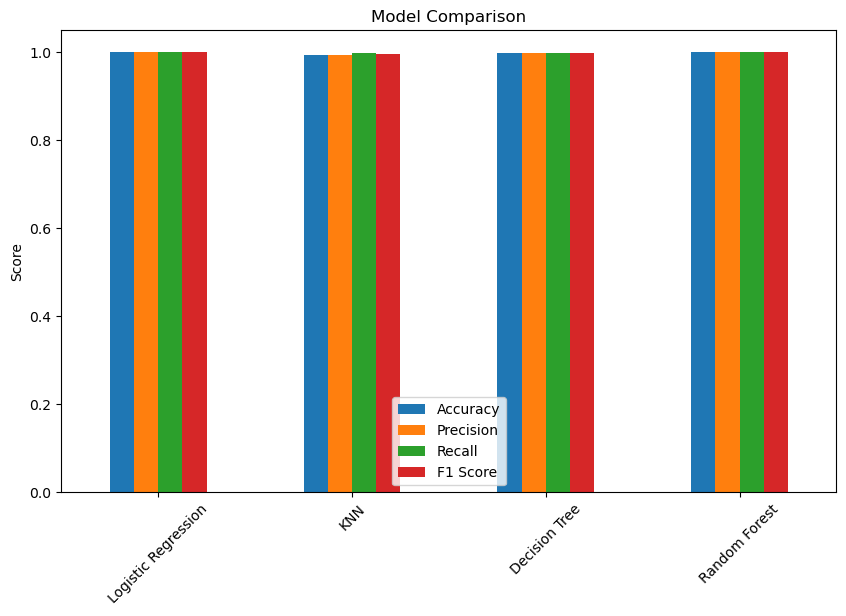

In [38]:
import matplotlib.pyplot as plt

results_df.plot(kind='bar', figsize=(10,6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

In [39]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 16.2 MB/s eta 0:00:00


In [40]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [41]:
model = XGBClassifier()

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [42]:
y_pred = model.predict(X_test)

In [44]:
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


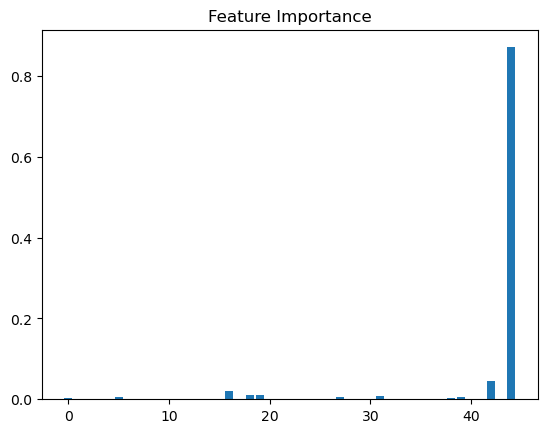

In [45]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.bar(range(len(importance)), importance)
plt.title("Feature Importance")
plt.show()

In [46]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.999914889995319
[[20024     4]
 [    0 26970]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20028
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     46998
   macro avg       1.00      1.00      1.00     46998
weighted avg       1.00      1.00      1.00     46998



In [47]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix

In [48]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),  # prevent overfitting
    
    Dense(64, activation='relu'),
    Dropout(0.3),
    
    Dense(1, activation='sigmoid')  # binary output
])

/Users/nandinibhatia/Desktop/sample_project/fraud-detection-project/env/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [50]:
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
4700/4700 ━━━━━━━━━━━━━━━━━━━━ 2s 408us/step - accuracy: 0.9660 - loss: 16.4464 - val_accuracy: 0.9907 - val_loss: 0.2747
Epoch 2/15
4700/4700 ━━━━━━━━━━━━━━━━━━━━ 2s 384us/step - accuracy: 0.9844 - loss: 0.6901 - val_accuracy: 0.9916 - val_loss: 0.0239
Epoch 3/15
4700/4700 ━━━━━━━━━━━━━━━━━━━━ 2s 381us/step - accuracy: 0.9875 - loss: 0.0474 - val_accuracy: 0.9933 - val_loss: 0.0201
Epoch 4/15
4700/4700 ━━━━━━━━━━━━━━━━━━━━ 2s 383us/step - accuracy: 0.9911 - loss: 0.0601 - val_accuracy: 0.9928 - val_loss: 0.0199
Epoch 5/15
4700/4700 ━━━━━━━━━━━━━━━━━━━━ 2s 378us/step - accuracy: 0.9918 - loss: 0.0368 - val_accuracy: 0.9958 - val_loss: 0.0135
Epoch 6/15
4700/4700 ━━━━━━━━━━━━━━━━━━━━ 2s 383us/step - accuracy: 0.9931 - loss: 0.0638 - val_accuracy: 0.9961 - val_loss: 0.0106
Epoch 7/15
4700/4700 ━━━━━━━━━━━━━━━━━━━━ 2s 377us/step - accuracy: 0.9947 - loss: 0.0250 - val_accuracy: 0.9923 - val_loss: 0.0454
Epoch 8/15
4700/4700 ━━━━━━━━━━━━━━━━━━━━ 2s 383us/step - accuracy: 0.9945 

In [51]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)

1469/1469 ━━━━━━━━━━━━━━━━━━━━ 0s 221us/step - accuracy: 0.9979 - loss: 0.0058
Loss: 0.005791661329567432
Accuracy: 0.9979360699653625


In [52]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int).flatten()

1469/1469 ━━━━━━━━━━━━━━━━━━━━ 0s 164us/step


In [53]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[19960    68]
 [   29 26941]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20028
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     46998
   macro avg       1.00      1.00      1.00     46998
weighted avg       1.00      1.00      1.00     46998



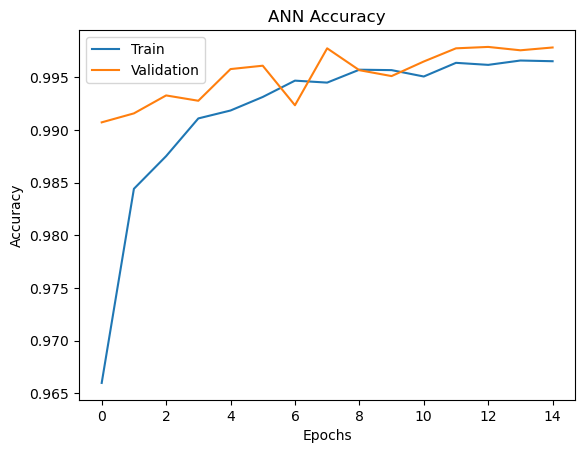

In [54]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("ANN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

In [55]:
ml_results = {
    "Logistic Regression": {},
    "KNN": {},
    "Decision Tree": {},
    "Random Forest": {},
    "XGBoost": {}
}

In [56]:
ann_loss, ann_acc = model.evaluate(X_test, y_test)

from sklearn.metrics import precision_score, recall_score, f1_score

ann_pred = (model.predict(X_test) > 0.5).astype(int).flatten()

ann_precision = precision_score(y_test, ann_pred)
ann_recall = recall_score(y_test, ann_pred)
ann_f1 = f1_score(y_test, ann_pred)

1469/1469 ━━━━━━━━━━━━━━━━━━━━ 0s 216us/step - accuracy: 0.9979 - loss: 0.0058
1469/1469 ━━━━━━━━━━━━━━━━━━━━ 0s 156us/step


In [58]:
import pandas as pd

final_results = {
    "Logistic Regression": results["Logistic Regression"],
    "KNN": results["KNN"],
    "Decision Tree": results["Decision Tree"],
    "Random Forest": results["Random Forest"],
    "ANN": {
        "Accuracy": ann_acc,
        "Precision": ann_precision,
        "Recall": ann_recall,
        "F1 Score": ann_f1
    }
}

df_results = pd.DataFrame(final_results).T
print(df_results)

                     Accuracy  Precision    Recall  F1 Score
Logistic Regression  0.999660   0.999666  0.999740  0.999703
KNN                  0.994553   0.993352  0.997182  0.995263
Decision Tree        0.998617   0.998813  0.998776  0.998795
Random Forest        0.999809   0.999741  0.999926  0.999833
ANN                  0.997936   0.997482  0.998925  0.998203


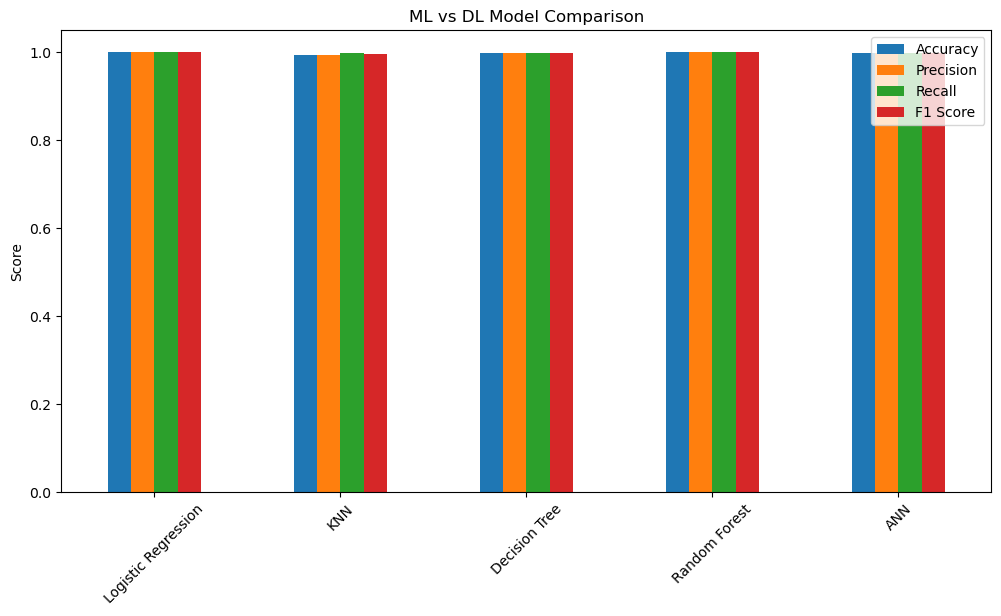

In [59]:
import matplotlib.pyplot as plt

df_results.plot(kind='bar', figsize=(12,6))
plt.title("ML vs DL Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()